In [2]:
#pip install scikit-learn==1.2.2

In [3]:
#pip install --upgrade imbalanced-learn

In [4]:
import sklearn
print(sklearn.__version__)

1.6.1


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv(r'C:\Users\chukw\Downloads\forage\BCG\data_for_predictions.csv')
df.head(5)

,Unnamed: 0,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,...,2,6,0,0,1,0,0,0,0,1
1,1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,...,76,4,1,0,0,0,0,1,0,0
2,2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,...,68,8,0,0,1,0,0,1,0,0
3,3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,...,69,9,0,0,0,1,0,1,0,0
4,4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,...,71,9,1,0,0,0,0,1,0,0


In [7]:
df

,Unnamed: 0,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,...,2,6,0,0,1,0,0,0,0,1
1,1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,...,76,4,1,0,0,0,0,1,0,0
2,2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,...,68,8,0,0,1,0,0,1,0,0
3,3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,...,69,9,0,0,0,1,0,1,0,0
4,4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,...,71,9,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14601,14601,18463073fb097fc0ac5d3e040f356987,4.508812,4.680707,0.000000,3.667360,0.0,1.291591,0.138305,0.000000,...,7,19,0,0,1,0,0,0,0,1
14602,14602,d0a6f71671571ed83b2645d23af6de00,3.858778,0.000000,2.260071,2.801191,0.0,2.161458,0.100167,0.091892,...,40,4,0,0,1,0,0,0,0,1
14603,14603,10e6828ddd62cbcf687cb74928c4c2d2,3.265996,0.000000,2.255273,2.281919,0.0,2.115943,0.116900,0.100015,...,46,10,0,0,1,0,0,0,0,1
14604,14604,1cf20fd6206d7678d5bcafd28c53b4db,2.120574,0.000000,0.000000,1.308351,0.0,0.912753,0.145711,0.000000,...,40,4,0,0,1,0,0,0,0,1


In [8]:
df = df.drop(columns = ["Unnamed: 0"], axis = 1)

In [9]:
df.shape

(14606, 63)

In [10]:
df['churn'].value_counts()

0    13187
1     1419
Name: churn, dtype: int64

## Fixing class proportions

In [12]:
# Separate majority and minority classes
minority_class = df[df["churn"] == 1]  # Replace "target" with your actual target column
majority_class = df[df["churn"] == 0]

# Randomly undersample the majority class
majority_class_undersampled = majority_class.sample(n=len(minority_class), random_state=42)

# Combine both classes
df_undersampled = pd.concat([majority_class_undersampled, minority_class])

# Shuffle dataset
df_undersampled = df_undersampled.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_undersampled["churn"].value_counts())  # Check class balance

0    1419
1    1419
Name: churn, dtype: int64


In [13]:
x = df.drop(['id','churn'], axis = 1)
y = df['churn']

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.ensemble import BalancedRandomForestClassifier 

In [15]:
x_train, x_test,y_train,y_test = train_test_split(x,y, test_size = 0.25)

In [16]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(10954, 61)
(3652, 61)
(10954,)
(3652,)


In [47]:
param_grid = {'n_estimators': [25,50,100,200,400], 
               'criterion': ['gini', 'entropy'], 
               'max_depth': [5,10,15],
              'min_samples_split': [2, 5, 10],
             }

brfc = BalancedRandomForestClassifier(random_state = 42)

grid = GridSearchCV(brfc, param_grid, cv=5,n_jobs=-1)
grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=BalancedRandomForestClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 15],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [25, 50, 100, 200, 400]})

In [79]:
best_model = grid.best_estimator_

In [48]:
print(grid.best_params_)

{'criterion': 'gini', 'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 400}


In [49]:

y_pred = grid.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.8083


In [50]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

Precision: 0.2293
Recall: 0.4000
F1 Score: 0.2915


In [51]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[2808  484]
 [ 216  144]]


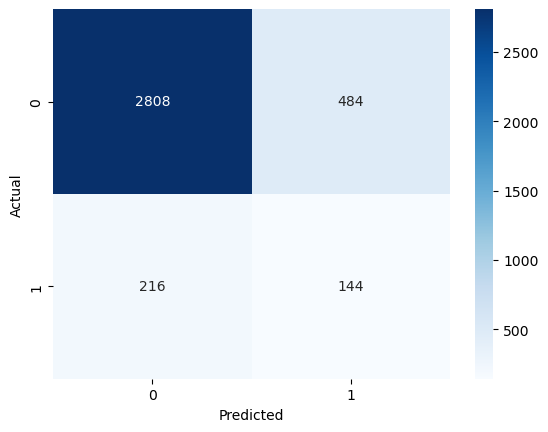

In [52]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

                                     Feature  Importance
11                      margin_gross_pow_ele    0.052647
12                        margin_net_pow_ele    0.052243
5                    forecast_meter_rent_12m    0.046172
0                                   cons_12m    0.046035
14                                net_margin    0.039612
..                                       ...         ...
54  channel_ewpakwlliwisiwduibdlfmalxowmwpci    0.002507
30                 var_6m_price_mid_peak_fix    0.001940
29                     var_6m_price_peak_fix    0.001700
4                   forecast_discount_energy    0.001612
46        peak_mid_peak_fix_max_monthly_diff    0.001291

[61 rows x 2 columns]


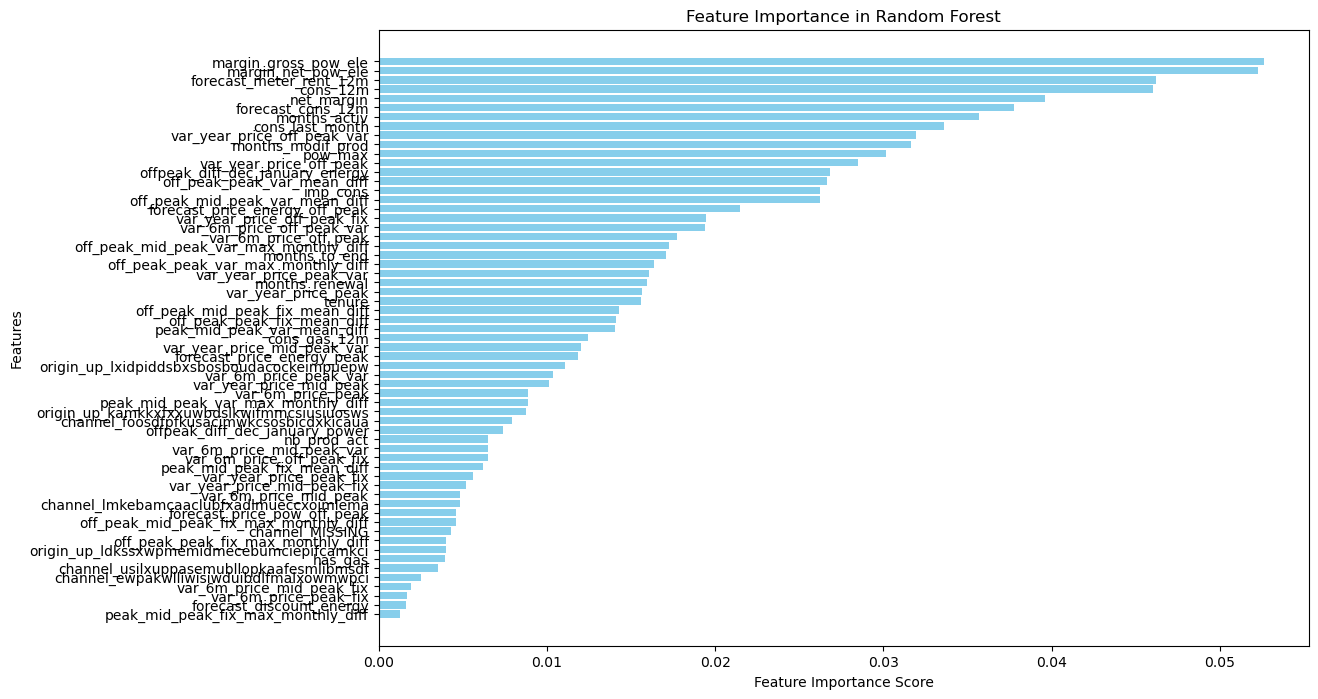

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0, '1.0')])

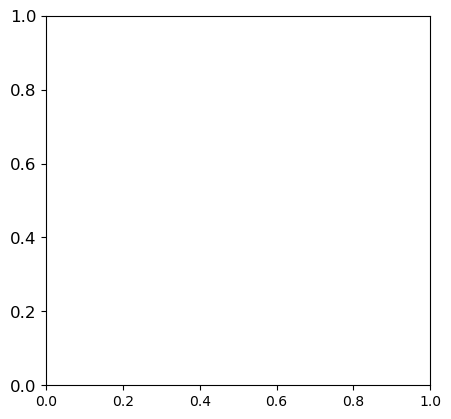

In [91]:
importances = best_model.feature_importances_
#sorted(zip(importances, x_train.columns), reverse=True)

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({'Feature': x_train.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print the top features
print(feature_importance_df)

# Plot feature importance
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance in Random Forest")
plt.gca().invert_yaxis()  # Flip y-axis to show the most important feature on top
plt.show()
plt.tight_layout()
plt.subplots_adjust(left=0.3)
plt.yticks(fontsize=12)

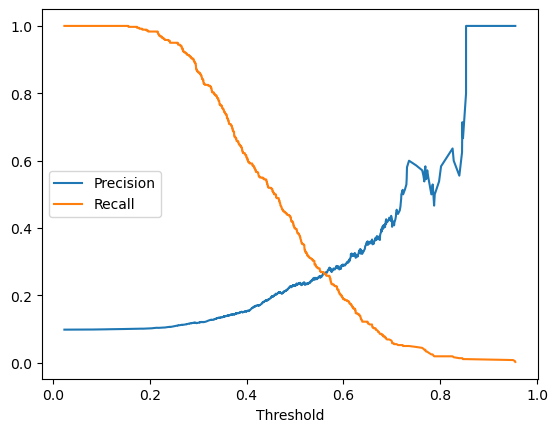

In [59]:
from sklearn.metrics import precision_recall_curve

# Get probabilities for the positive class
y_probs = grid.predict_proba(x_test)[:, 1] 

# Compute precision-recall tradeoff
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Plot the curve to find a better threshold
import matplotlib.pyplot as plt
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.show()

In [23]:
# param_grid = [
#     {
#         'clf': [SVC()],
#         'reduce_dims__n_components': [4, 6, 8],
#         'clf__kernel': ['linear', 'rbf'],
#         'clf__C': [0.1, 1, 10]
#     },
#     {
#         'clf': [RandomForestClassifier()],
#         'reduce_dims__n_components': [4, 6, 8],
#         'clf__n_estimators': [100, 200],
#         'clf__max_depth': [10, 20]
#     },
#     {
#         'clf': [xgb.XGBClassifier()],
#         'reduce_dims__n_components': [4, 6, 8],
#         'clf__loss': ['log_loss', 'exponential'],
#         'clf__criterion' :['friedman_mse', 'squared_error']
#     }
# ]


In [61]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

print(x_train_resampled.value_counts())
print(y_train_resampled.value_counts())

cons_12m  cons_gas_12m  cons_last_month  forecast_cons_12m  forecast_discount_energy  forecast_meter_rent_12m  forecast_price_energy_off_peak  forecast_price_energy_peak  forecast_price_pow_off_peak  has_gas  imp_cons  margin_gross_pow_ele  margin_net_pow_ele  nb_prod_act  net_margin   pow_max    var_year_price_off_peak_var  var_year_price_peak_var  var_year_price_mid_peak_var  var_year_price_off_peak_fix  var_year_price_peak_fix  var_year_price_mid_peak_fix  var_year_price_off_peak  var_year_price_peak  var_year_price_mid_peak  var_6m_price_off_peak_var  var_6m_price_peak_var  var_6m_price_mid_peak_var  var_6m_price_off_peak_fix  var_6m_price_peak_fix  var_6m_price_mid_peak_fix  var_6m_price_off_peak  var_6m_price_peak  var_6m_price_mid_peak  offpeak_diff_dec_january_energy  offpeak_diff_dec_january_power  off_peak_peak_var_mean_diff  peak_mid_peak_var_mean_diff  off_peak_mid_peak_var_mean_diff  off_peak_peak_fix_mean_diff  peak_mid_peak_fix_mean_diff  off_peak_mid_peak_fix_mean_diff 

In [65]:
rfc_2 = RandomForestClassifier(criterion = 'gini', max_depth = 15, min_samples_split = 5, n_estimators = 400)
rfc_2.fit(x_train_resampled, y_train_resampled)

y_pred = rfc_2.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

Accuracy: 0.8949
Precision: 0.3750
Recall: 0.1000
F1 Score: 0.1579


In [67]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[3232   60]
 [ 324   36]]


In [75]:
importances = rfc_2.feature_importances_
sorted(zip(importances, x_train_resampled.columns), reverse=True)

[(0.049136612923210754, 'origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws'),
 (0.044285794206977716, 'offpeak_diff_dec_january_power'),
 (0.0370788323637531, 'origin_up_ldkssxwpmemidmecebumciepifcamkci'),
 (0.03242373928122424, 'var_year_price_off_peak_fix'),
 (0.03130644234662186, 'var_year_price_off_peak'),
 (0.030891351583697144, 'cons_last_month'),
 (0.030080718929348292, 'cons_gas_12m'),
 (0.02655192167350704, 'margin_gross_pow_ele'),
 (0.026237302915217517, 'margin_net_pow_ele'),
 (0.025903893762636215, 'has_gas'),
 (0.02387950775608714, 'origin_up_lxidpiddsbxsbosboudacockeimpuepw'),
 (0.023347924676945814, 'pow_max'),
 (0.022147664760732995, 'channel_lmkebamcaaclubfxadlmueccxoimlema'),
 (0.021362773907098807, 'off_peak_peak_var_max_monthly_diff'),
 (0.021200272227787007, 'imp_cons'),
 (0.019994151391483687, 'var_6m_price_off_peak'),
 (0.01984052515687161, 'tenure'),
 (0.019595133890913077, 'net_margin'),
 (0.018982972713089234, 'peak_mid_peak_var_max_monthly_diff'),
 (0.01873037565635

## SMOTE (Synthetic Minority Oversampling Technique) using Standard Random Forest

In [100]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_validate
from statistics import mean

over_x, over_y = smote.fit_resample(x, y)
over_x_train, over_x_test, over_y_train, over_y_test = train_test_split(over_x, over_y, test_size=0.1, stratify=over_y)

SMOTE_SRF = RandomForestClassifier(criterion = 'gini', max_depth = 15, min_samples_split = 5, n_estimators = 400)

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
scoring = ('f1', 'recall', 'precision')

#Evaluate SMOTE SRF model
scores = cross_validate(SMOTE_SRF,over_x,over_y, scoring=scoring, cv=cv)

#Get average evaluation metrics
print('Mean f1: %.3f' % mean(scores['test_f1']))
print('Mean recall: %.3f' % mean(scores['test_recall']))
print('Mean precision: %.3f' % mean(scores['test_precision']))

#Randomly spilt dataset to test and train set
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, stratify=y)

#Train SMOTE SRF
SMOTE_SRF.fit(over_x_train, over_y_train)

#SMOTE SRF prediction result
#y_pred = SMOTE_SRF.predict(x_test)

#Create confusion matrix
# fig = plot_confusion_matrix(SMOTE_SRF, x_test, y_test, display_labels=['Will Not Buy', 'Will Buy'], cmap='Greens')
# plt.title('SMOTE + Tuned Random Forest Confusion Matrix')
# plt.show()

Mean f1: 0.944
Mean recall: 0.907
Mean precision: 0.983


In [102]:
y_pred = SMOTE_SRF.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.9555


In [107]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1314    5]
 [  60   82]]


                                       Feature  Importance
58  origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws    0.052047
2                              cons_last_month    0.036633
35              offpeak_diff_dec_january_power    0.035938
59  origin_up_ldkssxwpmemidmecebumciepifcamkci    0.035672
1                                 cons_gas_12m    0.030966
..                                         ...         ...
27                   var_6m_price_mid_peak_var    0.003617
46          peak_mid_peak_fix_max_monthly_diff    0.003290
29                       var_6m_price_peak_fix    0.003020
30                   var_6m_price_mid_peak_fix    0.002618
4                     forecast_discount_energy    0.001758

[61 rows x 2 columns]


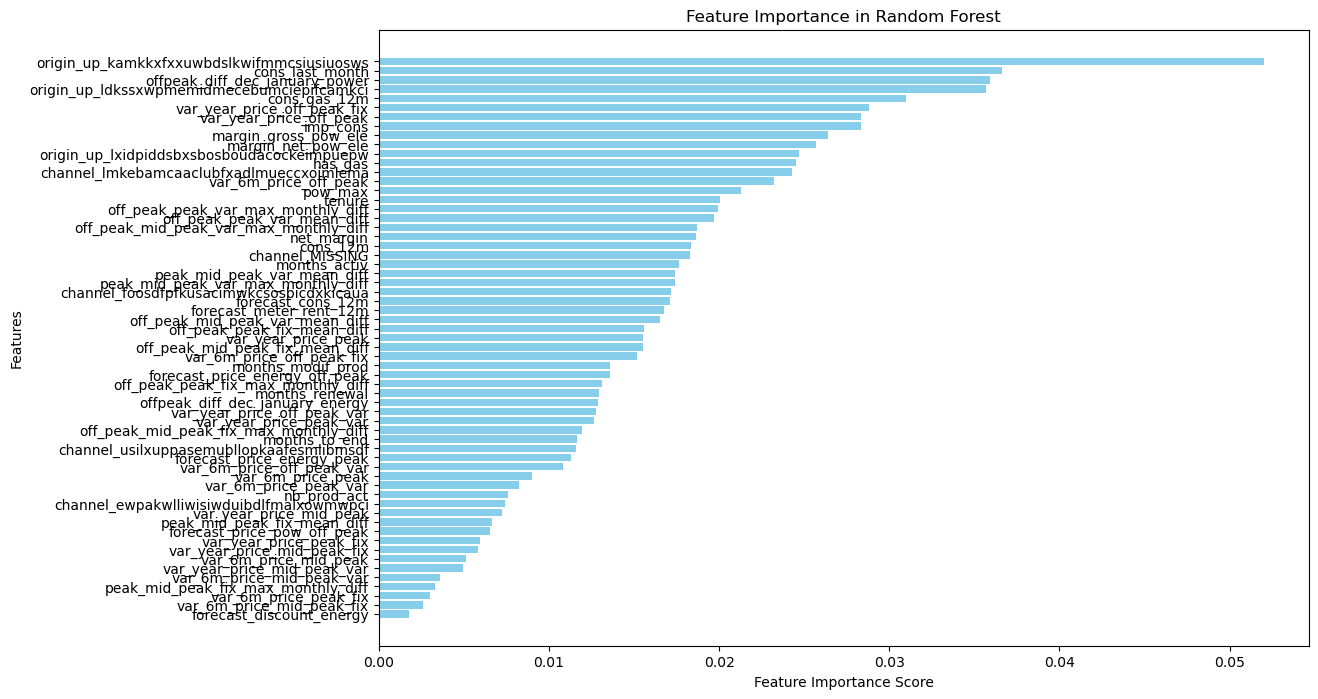

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0, '1.0')])

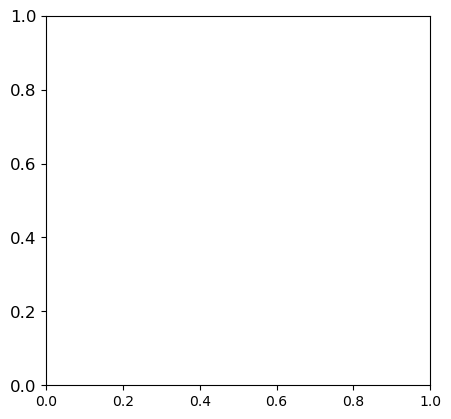

In [109]:
importances = SMOTE_SRF.feature_importances_
#sorted(zip(importances, x_train.columns), reverse=True)

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({'Feature': x_train.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print the top features
print(feature_importance_df)

# Plot feature importance
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance in Random Forest")
plt.gca().invert_yaxis()  # Flip y-axis to show the most important feature on top
plt.show()
plt.tight_layout()
plt.subplots_adjust(left=0.3)
plt.yticks(fontsize=12)